### PCA Analysis

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import geopandas as gpd
import os
import plotly.express as px
from scipy.spatial.distance import pdist, squareform


In [7]:
growth_rates_emissions_energy_prod_income_level_country_df = pd.read_csv("../datasets/growth_rates_emissions_energy_prod_income_level_country_df.csv", index_col=None)

1. Renewable Energy Adoption (from Energy Production & Use)
  - Renewable electricity output (% of total electricity output)

  - Electricity production from renewable sources, excluding hydroelectric (%)

  - Renewable energy consumption (% of total final energy consumption)

  - Combustible renewables and waste (% of total energy)

2. Energy Efficiency (from Energy Production & Use)
  - Energy intensity level of primary energy (MJ/$2017 PPP GDP)

  - GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent)

  - Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)

  - Fossil fuel energy consumption (% of total)

3. Sectoral Economic Growth (from Growth Rates)
  - Agriculture, forestry, and fishing, value added (annual % growth)

  - Industry (including construction), value added (annual % growth)

  - Manufacturing, value added (annual % growth)

  - Services, value added (annual % growth)

4. CO₂ Emissions & Environmental Impact (from Emissions)
  - Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)

  - CO₂ emissions per capita

  - CO₂ emissions from Power, Industry, Transport, and Agriculture

  - Total greenhouse gas emissions excluding LULUCF

  - Carbon intensity of GDP

In [9]:
renewable_series = [
    "Renewable electricity output (% of total electricity output)",
    "Electricity production from renewable sources, excluding hydroelectric (% of total)",
    "Renewable energy consumption (% of total final energy consumption)",
    "Combustible renewables and waste (% of total energy)"
]

In [10]:
efficiency_series = [
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)",
    "GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent)",
    "Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)",
    "Fossil fuel energy consumption (% of total)"
]

In [11]:
growth_series = [
    "Agriculture, forestry, and fishing, value added (annual % growth)",
    "Industry (including construction), value added (annual % growth)",
    "Manufacturing, value added (annual % growth)",
    "Services, value added (annual % growth)"
]

In [12]:
emission_series = [
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)",
    "Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP)",
    "Total greenhouse gas emissions excluding LULUCF (Mt CO2e)",
    "Total greenhouse gas emissions excluding LULUCF per capita (t CO2e/capita)"
]

In [13]:
selected_series = renewable_series + efficiency_series + growth_series + emission_series

In [14]:
def plot_country_distance_matrix_interactive(pivot_df, income_level, metric='euclidean', save_dir='../plots'):
    distance_matrix = pd.DataFrame(
        squareform(pdist(pivot_df, metric=metric)),
        index=pivot_df.index,
        columns=pivot_df.index
    )

    fig = px.imshow(
        distance_matrix,
        labels=dict(x="Country", y="Country", color="Distance"),
        x=distance_matrix.columns,
        y=distance_matrix.index,
        color_continuous_scale="Viridis",
        text_auto=".0f"  # Display distance values inside the cells
    )

    fig.update_layout(
        title=f"{metric.title()} Distance Between Countries | Income Level: {income_level}",
        width=1000,
        height=1000
    )
    print(distance_matrix)
    
    # Save as HTML
    filename = f"{save_dir}/{income_level.replace(' ', '_')}_{metric}_distance_heatmap.html"
    fig.write_html(filename)
    fig.show()

In [15]:
def run_pca_for_income_level(income_level):
    data = growth_rates_emissions_energy_prod_income_level_country_df[
        (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
        (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].isin(selected_series))
    ].copy()

    data.iloc[:, 5:-1] = data.iloc[:, 5:-1].apply(pd.to_numeric, errors="coerce")
    data["Series Avg"] = data.iloc[:, 5:-1].mean(axis=1)

    pivot_df = data.pivot_table(index="Country Name", columns="Series Name", values="Series Avg")
    pivot_df = pivot_df.dropna()

    plot_country_distance_matrix_interactive(pivot_df, income_level=income_level, metric='euclidean')
    
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pivot_df)

    pca = PCA()
    pca_result = pca.fit_transform(scaled_data)

    explained_var = pca.explained_variance_ratio_

    # Scree plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_var) + 1), explained_var.cumsum(), marker='o')
    plt.title(f'Cumulative Explained Variance by PCA Components | {income_level}')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()

    # 2D Scatter plot using first two components
    pca_df = pd.DataFrame(pca_result[:, :2], columns=['PC1', 'PC2'], index=pivot_df.index)
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2')
    plt.title(f'PCA Scatter Plot | {income_level} Countries')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

    return pca, pca_df, pivot_df.columns

Country Name      Congo, Dem. Rep.    Ethiopia  Mozambique       Niger  \
Country Name                                                             
Congo, Dem. Rep.          0.000000  241.478061  258.698423  200.817487   
Ethiopia                241.478061    0.000000   92.513671  422.537480   
Mozambique              258.698423   92.513671    0.000000  440.721382   
Niger                   200.817487  422.537480  440.721382    0.000000   
Sudan                   192.019825  396.627146  432.881703  108.405367   
Togo                    102.051540  329.147470  340.807803  118.501543   
Zambia                   37.047128  263.770516  276.754823  184.204761   

Country Name           Sudan        Togo      Zambia  
Country Name                                          
Congo, Dem. Rep.  192.019825  102.051540   37.047128  
Ethiopia          396.627146  329.147470  263.770516  
Mozambique        432.881703  340.807803  276.754823  
Niger             108.405367  118.501543  184.204761  
Sud

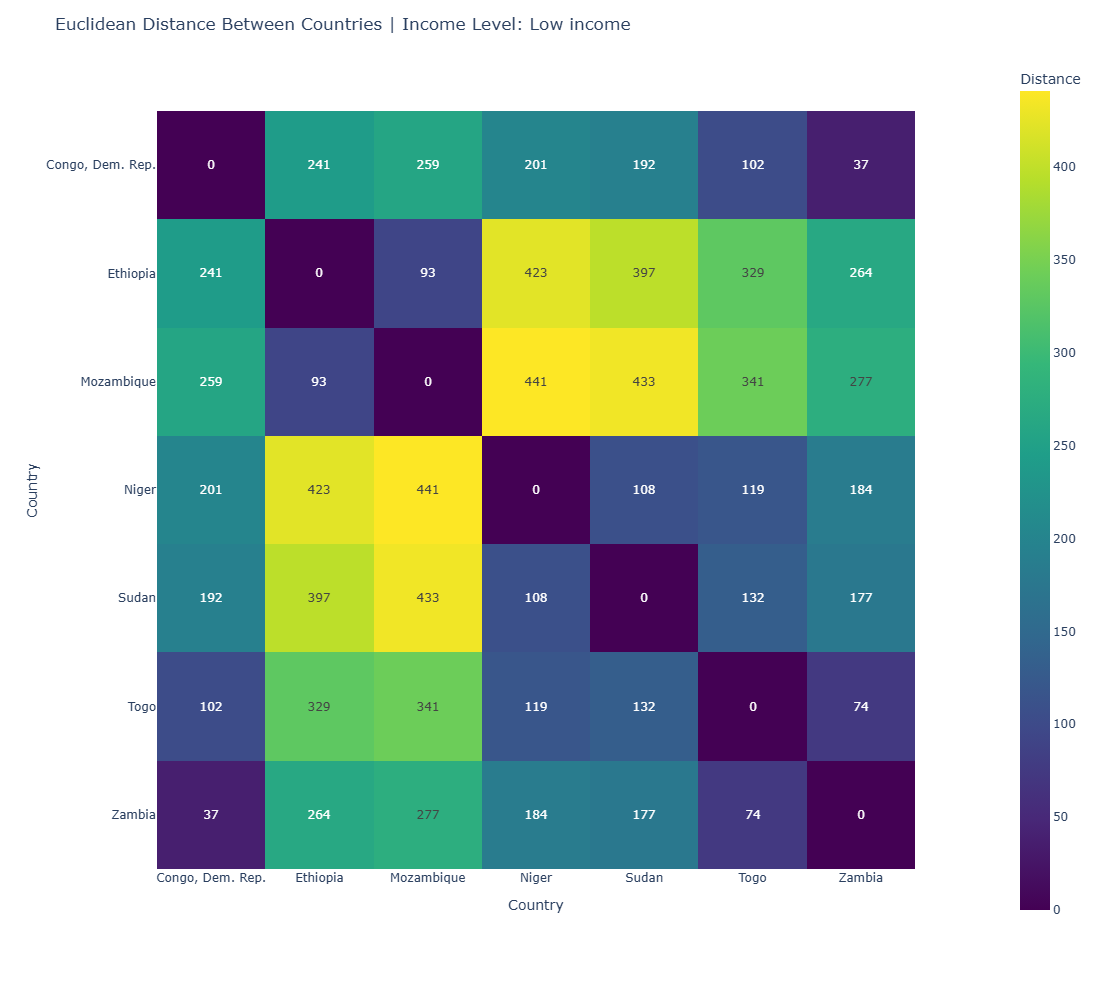

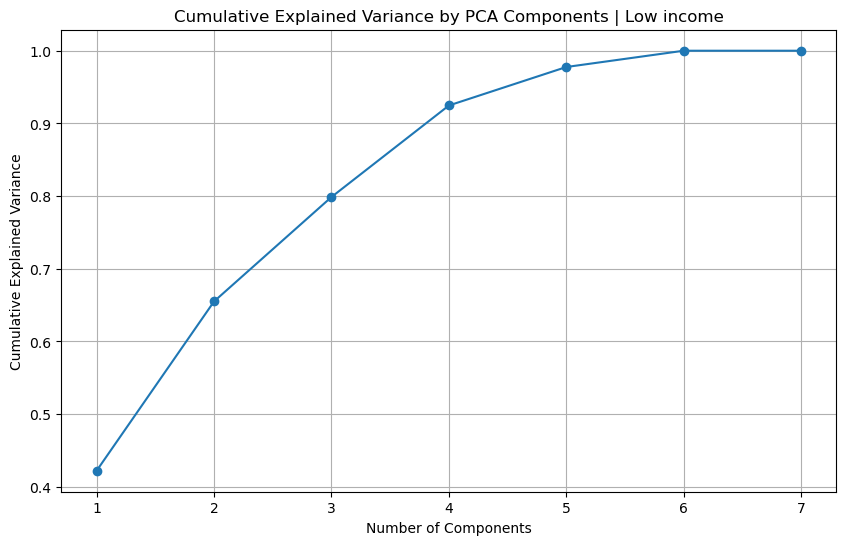

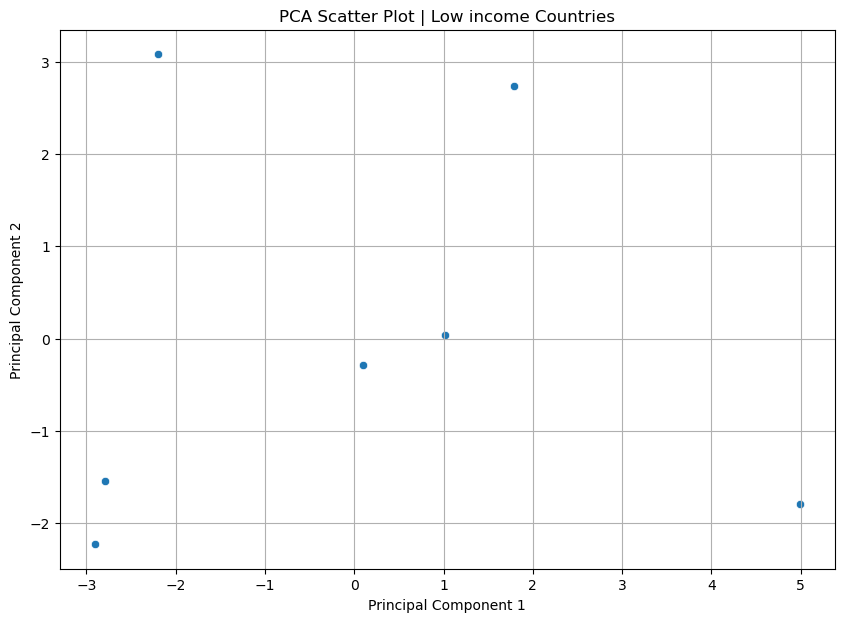

In [16]:
pca_low, pca_coordinates_low, series_labels_low = run_pca_for_income_level("Low income")

Country Name            Algeria       Angola   Bangladesh        Benin  \
Country Name                                                             
Algeria                0.000000   203.688239   101.504614   245.826135   
Angola               203.688239     0.000000   151.095789   110.896219   
Bangladesh           101.504614   151.095789     0.000000   204.796330   
Benin                245.826135   110.896219   204.796330     0.000000   
Bolivia              189.408232    80.609016   165.670563   107.343186   
Cambodia             231.268918    92.057564   183.681228    28.070254   
Cameroon             249.651307    57.390732   198.309762    98.069993   
Congo, Rep.          246.061543    55.992300   195.251651   123.824247   
Cote d'Ivoire        231.041694    63.948704   185.551977    56.105166   
Egypt, Arab Rep.      90.777340   270.714157   154.334821   323.508021   
El Salvador          229.502948    70.800966   195.696864    91.827020   
Ghana                233.423599    46.

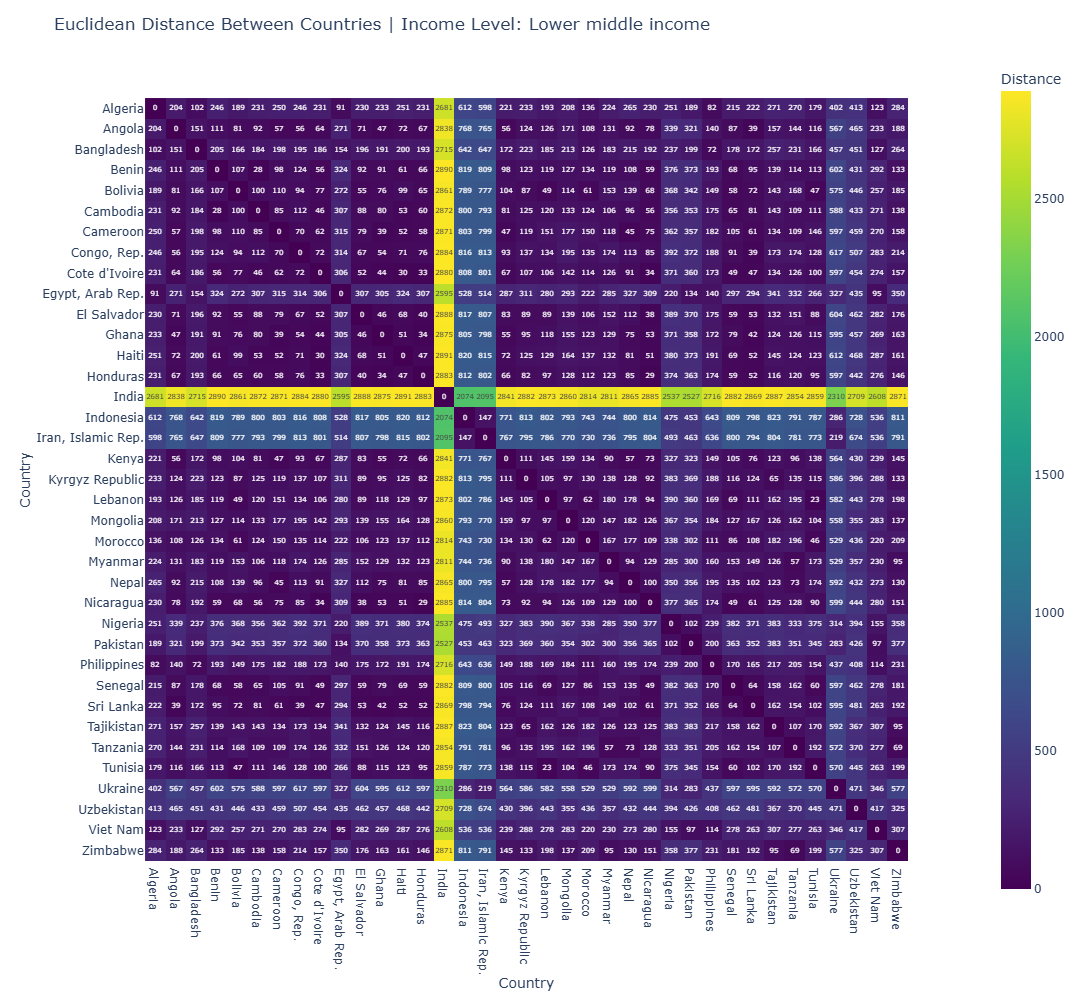

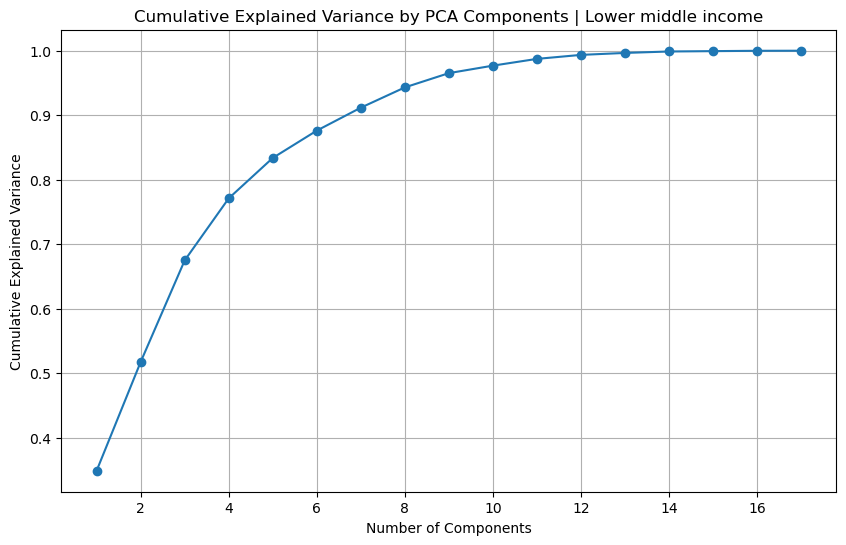

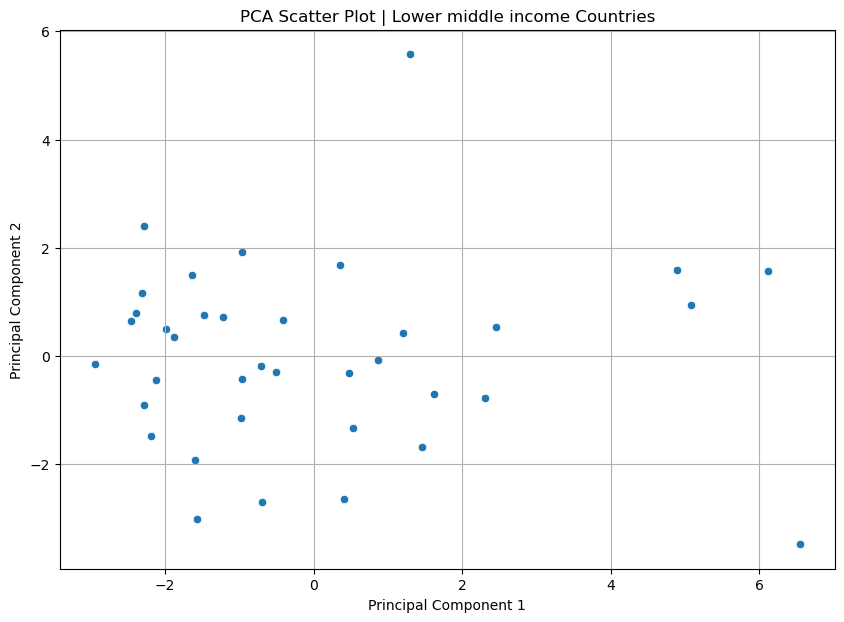

In [17]:
pca_lower_middle, pca_coordinates_lower_middle, series_labels_lower_middle = run_pca_for_income_level("Lower middle income")

Country Name                Albania   Argentina      Armenia   Azerbaijan  \
Country Name                                                                
Albania                    0.000000  353.560838    95.418147   173.504618   
Argentina                353.560838    0.000000   350.446280   328.533420   
Armenia                   95.418147  350.446280     0.000000    93.025310   
Azerbaijan               173.504618  328.533420    93.025310     0.000000   
Belarus                  198.070055  281.853681   130.080861    55.973961   
Bosnia and Herzegovina   128.706590  347.722706    62.919456    56.268667   
Botswana                  98.527466  347.104725    82.877100   156.382615   
Brazil                  1082.906473  743.889059  1085.462232  1047.916232   
Colombia                 176.134270  181.633649   197.103263   213.697154   
Costa Rica                37.062281  348.568018   116.786044   197.073159   
Dominican Republic        96.331784  318.196931    85.541887   152.830781   

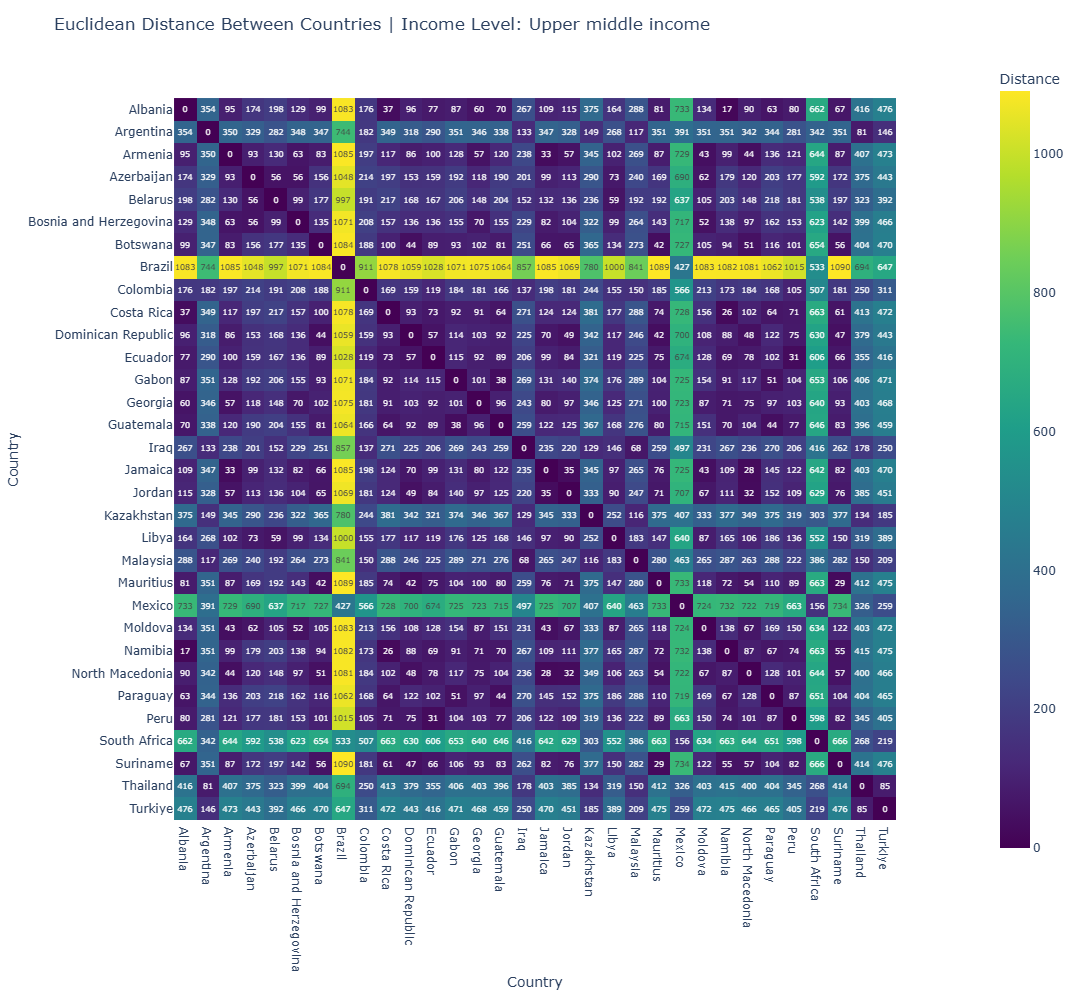

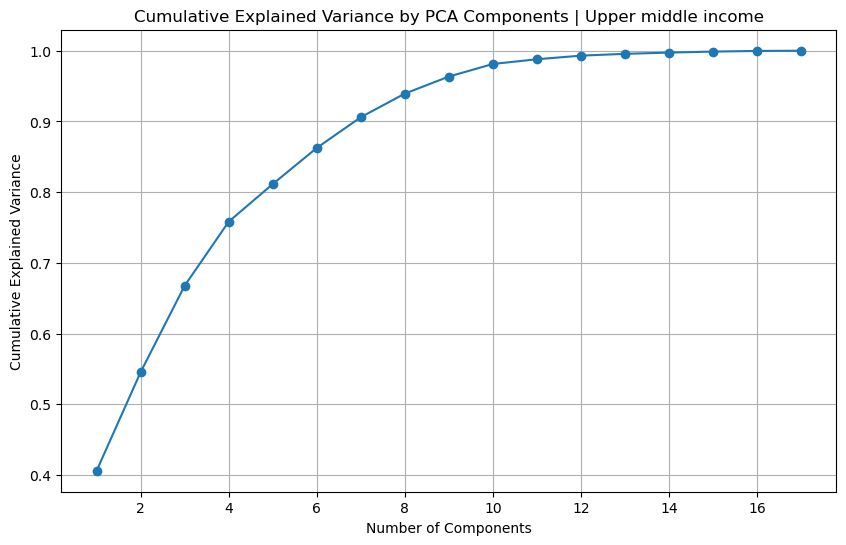

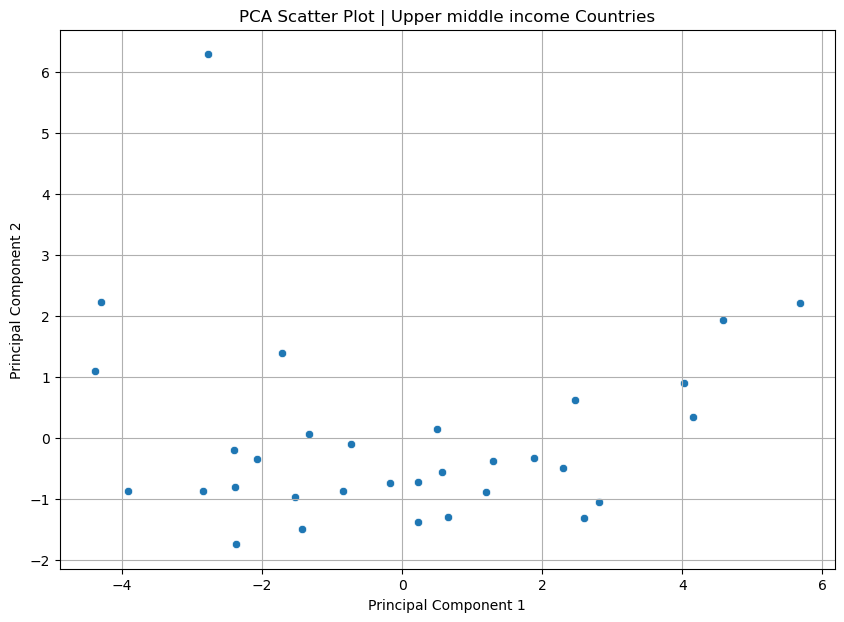

In [18]:
pca_upper, pca_coordinates_upper, series_labels_upper = run_pca_for_income_level("Upper middle income")

In [19]:
print(f"PCA for low income countries:\n", pca_coordinates_low)
print(f"PCA for lower middle income countries:\n", pca_coordinates_lower_middle)
print(f"PCA for upper income countries:\n", pca_coordinates_upper)


PCA for low income countries:
                        PC1       PC2
Country Name                        
Congo, Dem. Rep. -2.200238  3.083218
Ethiopia         -2.904253 -2.230247
Mozambique       -2.796460 -1.548751
Niger             1.794707  2.743065
Sudan             4.988857 -1.795602
Togo              1.014333  0.040091
Zambia            0.103053 -0.291774
PCA for lower middle income countries:
                          PC1       PC2
Country Name                          
Algeria             2.448859  0.541382
Angola             -1.877612  0.351011
Bangladesh         -1.634808  1.494928
Benin              -1.478399  0.753161
Bolivia             0.479561 -0.322196
Cambodia           -2.283486  2.406054
Cameroon           -2.195470 -1.480794
Congo, Rep.        -1.594305 -1.916326
Cote d'Ivoire      -1.995457  0.495738
Egypt, Arab Rep.    1.206741  0.420665
El Salvador        -0.701984 -2.702070
Ghana              -2.397066  0.786236
Haiti              -1.573646 -3.012418
Honduras   

In [20]:
def plot_pca_with_labels(pca_df, income_level):
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x="PC1", y="PC2", data=pca_df, s=100)

    for country, row in pca_df.iterrows():
        plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, country, fontsize=9)

    plt.title(f"PCA Scatter Plot with Country Labels | {income_level}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

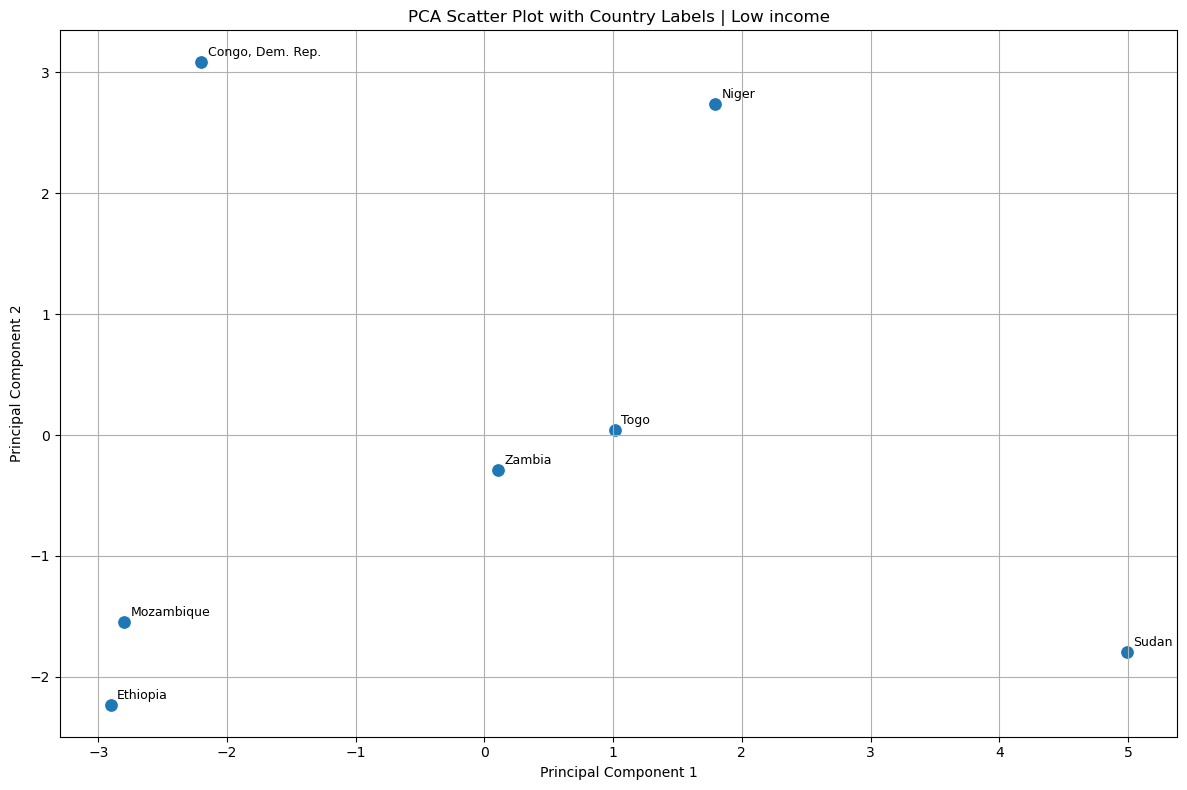

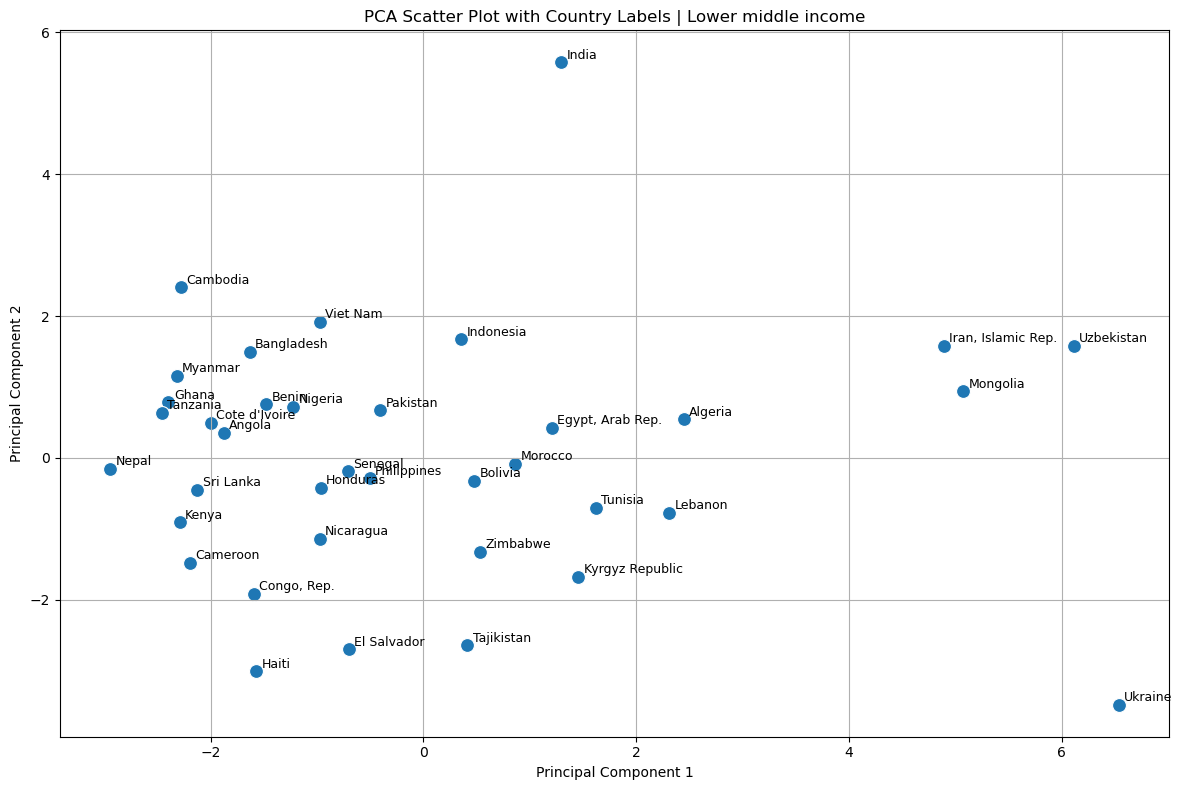

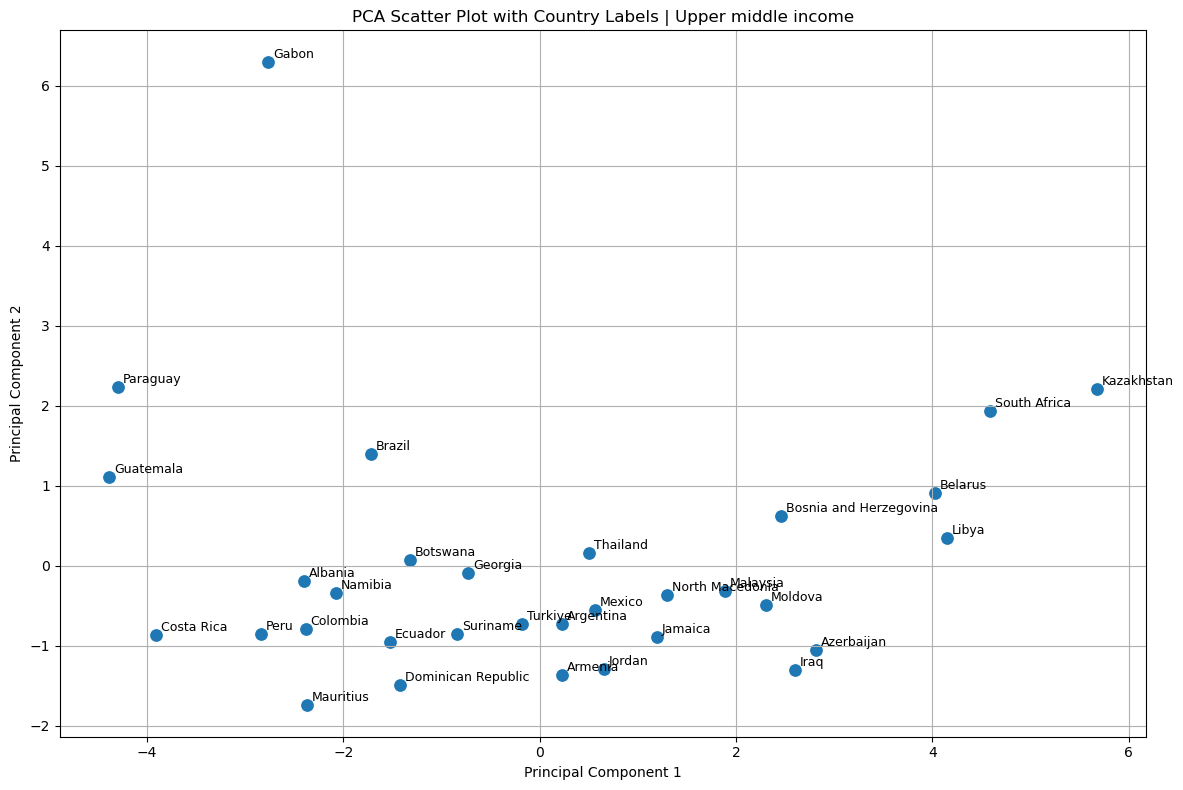

In [21]:
plot_pca_with_labels(pca_coordinates_low, "Low income")
plot_pca_with_labels(pca_coordinates_lower_middle, "Lower middle income")
plot_pca_with_labels(pca_coordinates_upper, "Upper middle income")

In [22]:
pca_coordinates_low.to_csv("../datasets/pca_coordinates_low.csv")
pca_coordinates_lower_middle.to_csv("../datasets/pca_coordinates_lower_middle.csv")
pca_coordinates_upper.to_csv("../datasets/pca_coordinates_upper.csv")

## KMeanse Clustering

In [24]:
def run_kmeans_clustering(pca_coordinates, income_level, max_k=12):
    pca_df = pd.DataFrame(pca_coordinates, columns=["PC1", "PC2"])
    pca_df["Country Name"] = pca_coordinates.index

    max_k = min(max_k, len(pca_df) - 1, 12)

    inertias = []
    silhouette_scores = []

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pca_df[["PC1", "PC2"]])
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(pca_df[["PC1", "PC2"]], labels))

    plt.figure(figsize=(10, 5))
    plt.plot(range(2, max_k + 1), inertias, marker='o')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method for Optimal k | {income_level}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
    print(f"Optimal number of clusters for {income_level}: {optimal_k}")

    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    pca_df["Cluster"] = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

    plt.figure(figsize=(10, 6))
    for cluster_id in sorted(pca_df["Cluster"].unique()):
        cluster_data = pca_df[pca_df["Cluster"] == cluster_id]
        plt.scatter(cluster_data["PC1"], cluster_data["PC2"], label=f"Cluster {cluster_id}", alpha=0.7)
        for _, row in cluster_data.iterrows():
            plt.text(row["PC1"] + 0.1, row["PC2"] + 0.1, row["Country Name"], fontsize=8)

    plt.title(f"KMeans Clustering on PCA Coordinates | {income_level}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pca_df

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

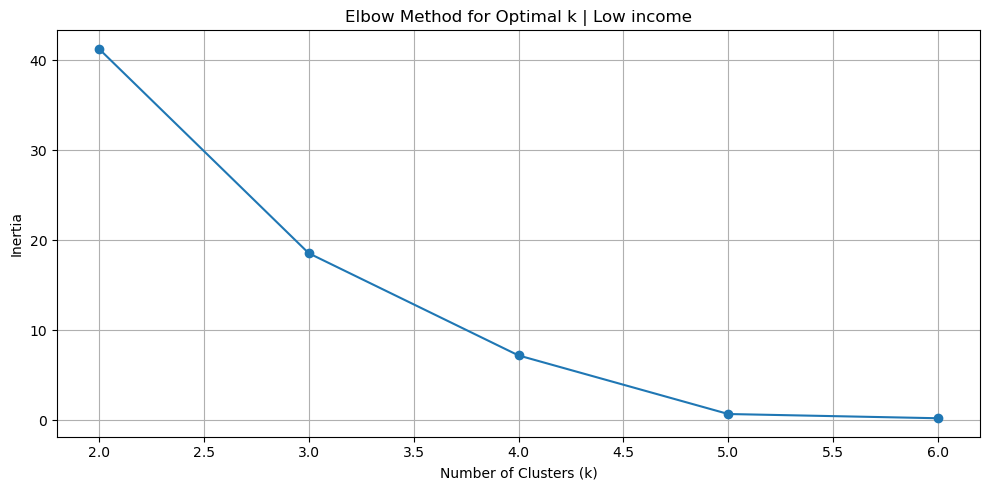

Optimal number of clusters for Low income: 5


C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



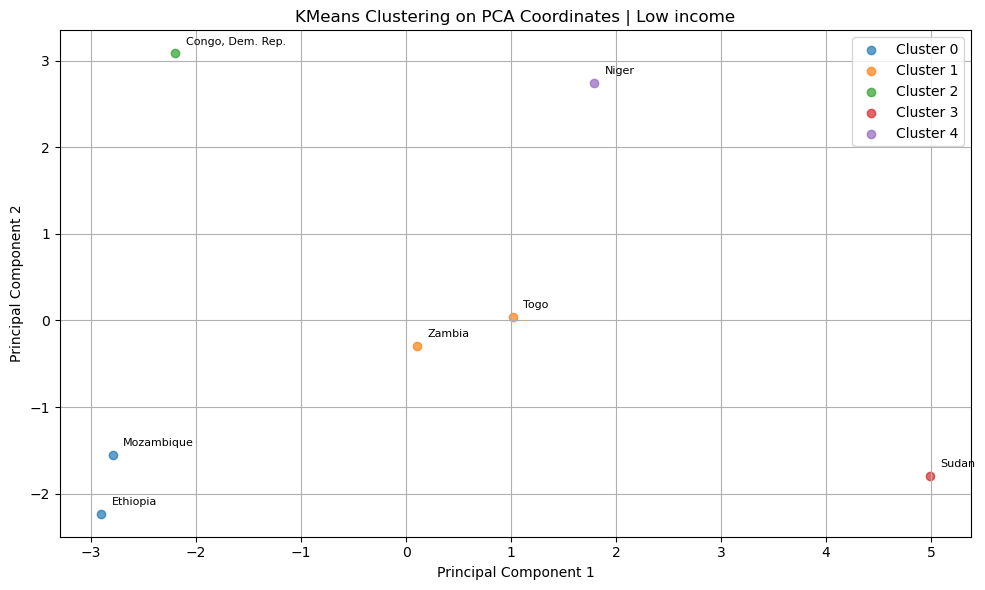

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

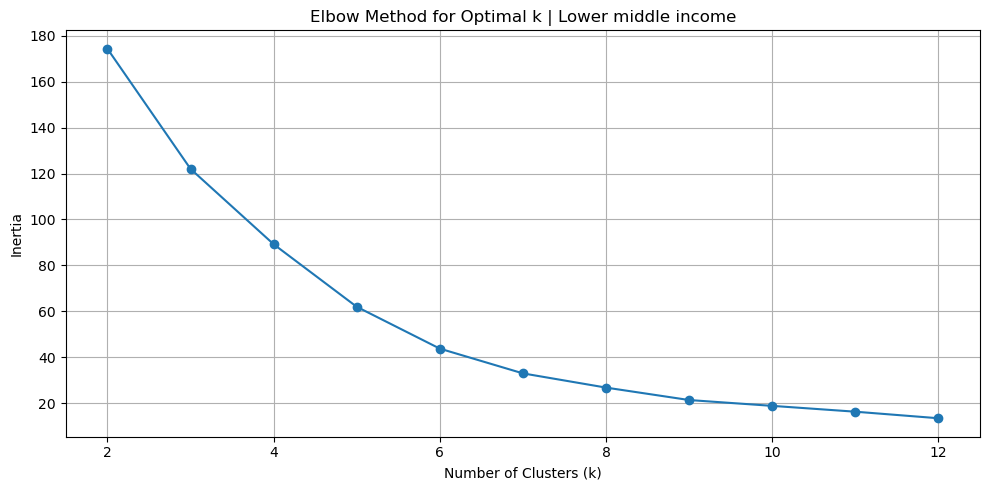

Optimal number of clusters for Lower middle income: 2


C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



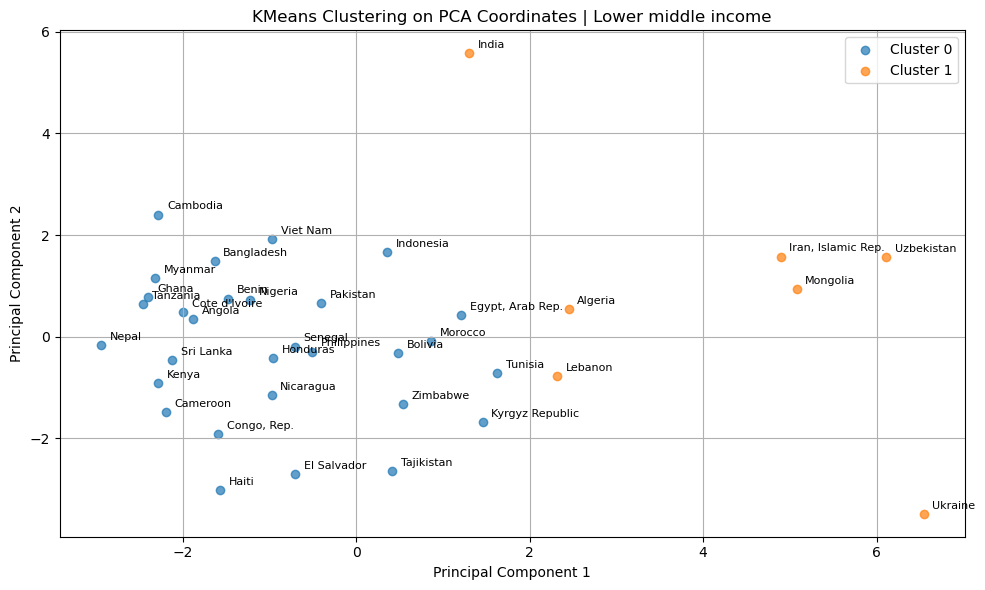

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

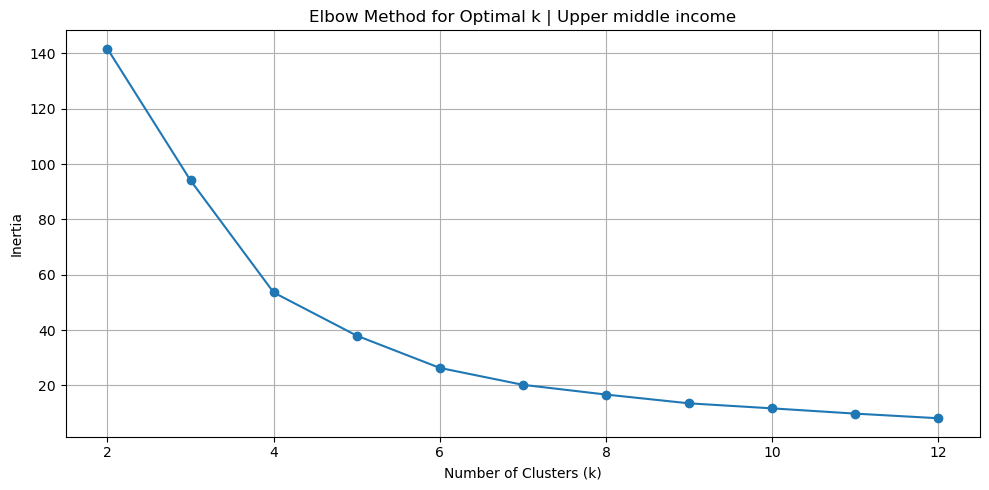

Optimal number of clusters for Upper middle income: 4


C:\Users\Nazm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



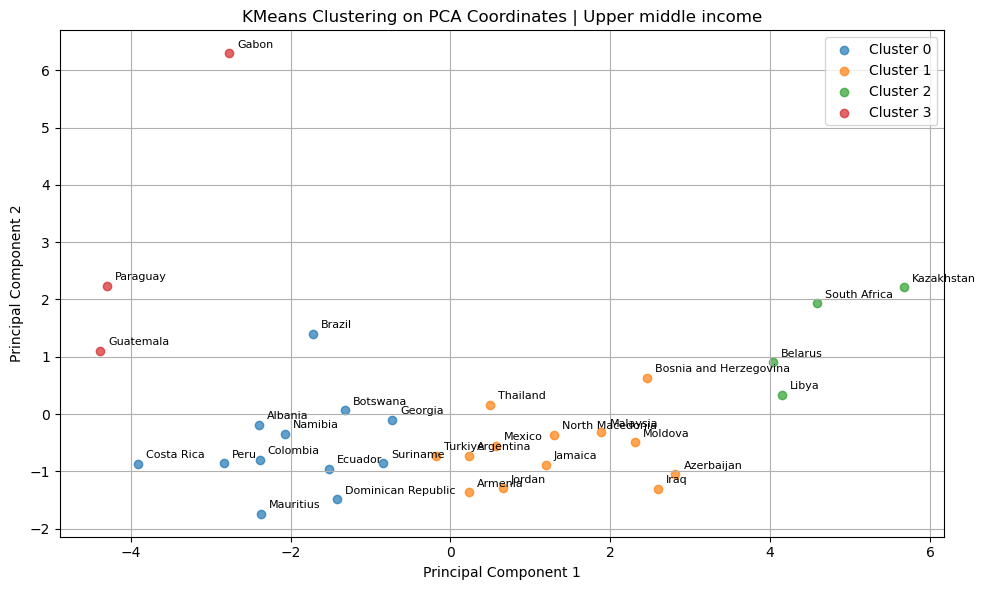

In [25]:
clustered_low = run_kmeans_clustering(pca_coordinates_low, "Low income")
clustered_lower_middle = run_kmeans_clustering(pca_coordinates_lower_middle, "Lower middle income")
clustered_upper = run_kmeans_clustering(pca_coordinates_upper, "Upper middle income")

In [26]:
clustered_low.to_csv("../datasets/clustered_low.csv", index=False)
clustered_lower_middle.to_csv("../datasets/clustered_lower_middle.csv", index=False)
clustered_upper.to_csv("../datasets/clustered_upper.csv", index=False)

### Profile Clusters

In [28]:
def merge_clusters_with_original(df_original, pca_coords, cluster_labels, income_level):
    df_filtered = df_original[df_original["Income Level"] == income_level].copy()

    year_cols = [col for col in df_filtered.columns if "_20" in col or "_19" in col or "_2023" in col]

    df_country_avg = df_filtered.groupby("Country Name")[year_cols].mean().reset_index()

    if len(df_country_avg) != len(cluster_labels):
        raise ValueError(f"Mismatch in rows: {len(df_country_avg)} countries vs {len(cluster_labels)} cluster labels")

    df_country_avg["Cluster"] = cluster_labels
    return df_country_avg

In [29]:
def plot_cluster_profiles(df, cluster_column, income_level):
    """
    Plots average profiles for each cluster within a given income level.
    Assumes input df contains the cluster labels and original (non-PCA) indicators.
    """
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    profile_data = df.groupby(cluster_column)[numeric_cols].mean()

    profile_data_normalized = (profile_data - profile_data.min()) / (profile_data.max() - profile_data.min())

    plt.figure(figsize=(12, 6))
    for idx in profile_data_normalized.index:
        plt.plot(profile_data_normalized.columns, profile_data_normalized.loc[idx], label=f"Cluster {idx}", marker='o')

    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Normalized Average Value")
    plt.title(f"Cluster Profiles based on Key Indicators | {income_level}")
    plt.legend(title="Clusters")
    plt.tight_layout()
    plt.show()

In [30]:
used_countries = pd.DataFrame(pca_coordinates_low, columns=["PC1", "PC2"]).index.tolist()

df_low_used = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == "Low income") &
    (growth_rates_emissions_energy_prod_income_level_country_df["Country Name"].isin(used_countries))
]

merged_low = merge_clusters_with_original(
    df_low_used,
    pca_coordinates_low,
    clustered_low["Cluster"].values,
    "Low income"
)

merged_low = merged_low.merge(
    growth_rates_emissions_energy_prod_income_level_country_df[["Country Name", "Income Level"]].drop_duplicates(),
    on="Country Name",
    how="left"
)

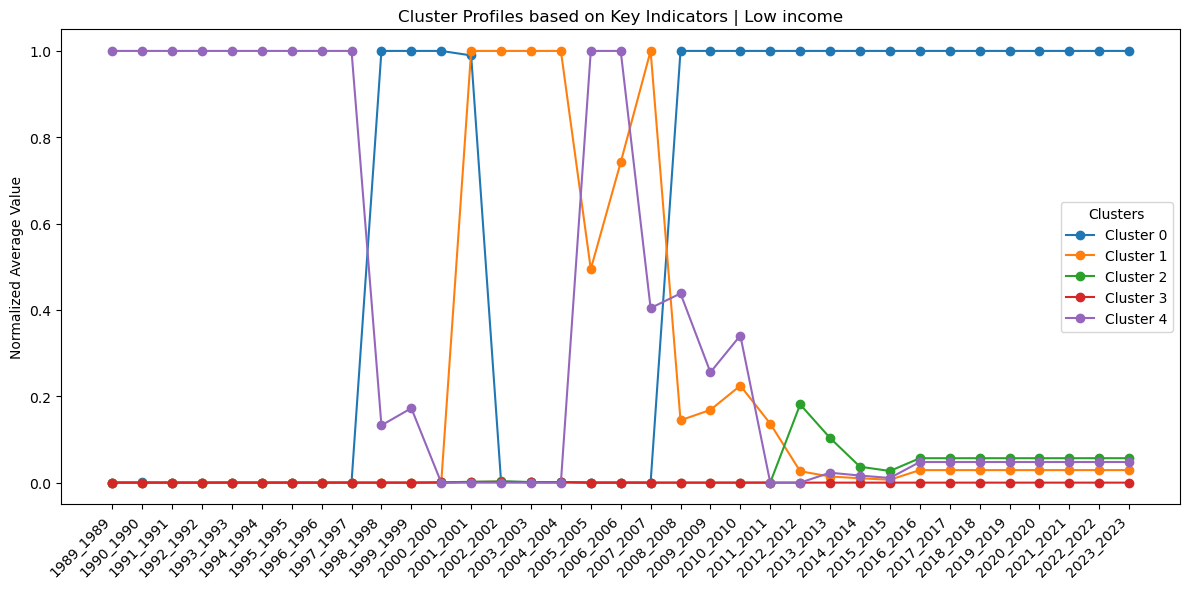

In [31]:
plot_cluster_profiles(merged_low, cluster_column="Cluster", income_level="Low income")

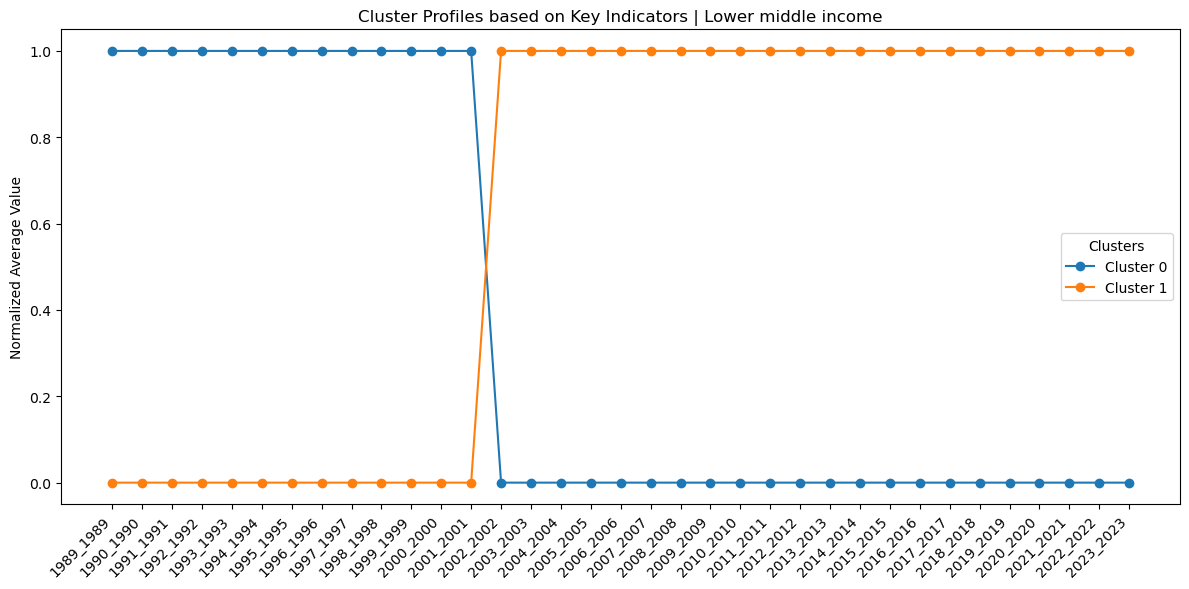

In [32]:
used_countries_lower = pd.DataFrame(pca_coordinates_lower_middle, columns=["PC1", "PC2"]).index.tolist()

df_lower_middle_used = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == "Lower middle income") &
    (growth_rates_emissions_energy_prod_income_level_country_df["Country Name"].isin(used_countries_lower))
]

merged_lower_middle = merge_clusters_with_original(
    df_lower_middle_used,
    pca_coordinates_lower_middle,
    clustered_lower_middle["Cluster"].values,
    "Lower middle income"
)

merged_lower_middle = merged_lower_middle.merge(
    growth_rates_emissions_energy_prod_income_level_country_df[["Country Name", "Income Level"]].drop_duplicates(),
    on="Country Name",
    how="left"
)

plot_cluster_profiles(merged_lower_middle, cluster_column="Cluster", income_level="Lower middle income")

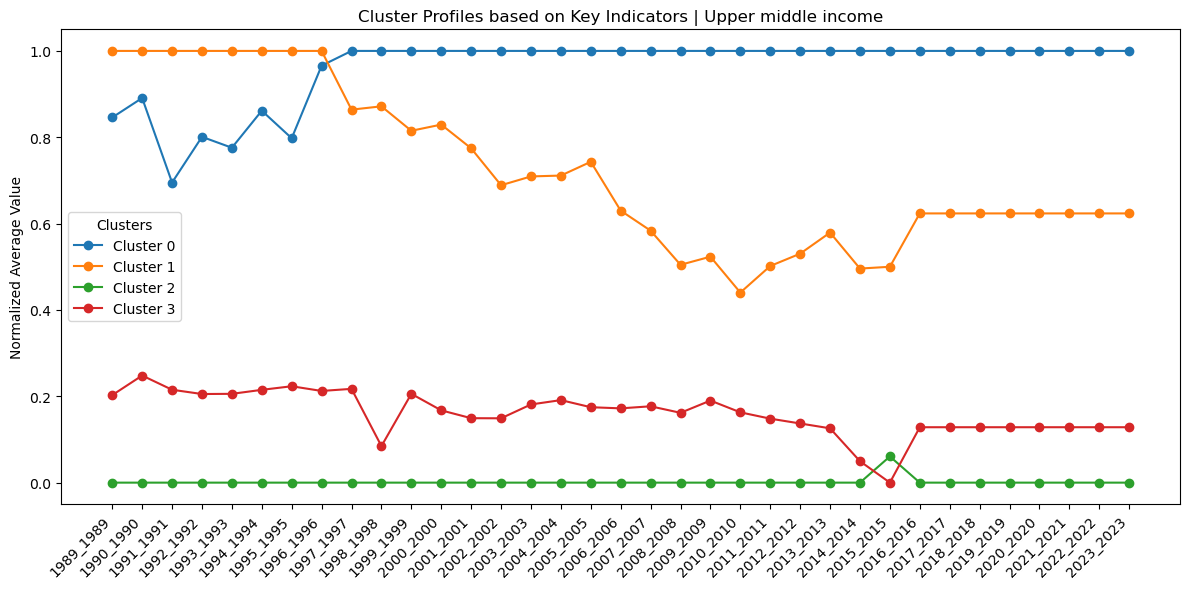

In [33]:
used_countries_upper = pd.DataFrame(pca_coordinates_upper, columns=["PC1", "PC2"]).index.tolist()

df_upper_used = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == "Upper middle income") &
    (growth_rates_emissions_energy_prod_income_level_country_df["Country Name"].isin(used_countries_upper))
]

merged_upper = merge_clusters_with_original(
    df_upper_used,
    pca_coordinates_upper,
    clustered_upper["Cluster"].values,
    "Upper middle income"
)

merged_upper = merged_upper.merge(
    growth_rates_emissions_energy_prod_income_level_country_df[["Country Name", "Income Level"]].drop_duplicates(),
    on="Country Name",
    how="left"
)

plot_cluster_profiles(merged_upper, cluster_column="Cluster", income_level="Upper middle income")

### Map Clusters Geographically

In [35]:
shapefile_dir = '../datasets/ne_110m_admin_0_countries'
# shapefile_dir = '/content/ne'

files = os.listdir(shapefile_dir)
print(files)

shapefile_path = os.path.join(shapefile_dir, 'ne_110m_admin_0_countries.shp')

world = gpd.read_file(shapefile_path)

['ne_110m_admin_0_countries.cpg', 'ne_110m_admin_0_countries.dbf', 'ne_110m_admin_0_countries.prj', 'ne_110m_admin_0_countries.README.html', 'ne_110m_admin_0_countries.shp', 'ne_110m_admin_0_countries.shx', 'ne_110m_admin_0_countries.VERSION.txt']


In [36]:
def plot_geographic_clusters(merged_df, income_level, shapefile_path):
    world = gpd.read_file(shapefile_path)

    data = merged_df[merged_df["Income Level"] == income_level]
    country_clusters = data[["Country Name", "Cluster"]].drop_duplicates(subset="Country Name")

    rename_map = {
        "Congo, Dem. Rep.": "Democratic Republic of the Congo",
        "Congo, Rep.": "Republic of the Congo",
        "Egypt, Arab Rep.": "Egypt",
        "Gambia, The": "Gambia",
        "Iran, Islamic Rep.": "Iran",
        "Kyrgyz Republic": "Kyrgyzstan",
        "Lao PDR": "Laos",
        "Russian Federation": "Russia",
        "Slovak Republic": "Slovakia",
        "Syrian Arab Republic": "Syria",
        "Venezuela, RB": "Venezuela",
        "Yemen, Rep.": "Yemen"
    }
    country_clusters["Country Name"] = country_clusters["Country Name"].replace(rename_map)

    merged_map = world.merge(country_clusters, how="left", left_on="NAME", right_on="Country Name")

    fig, ax = plt.subplots(figsize=(15, 10))
    merged_map.plot(column="Cluster", cmap="Set3", linewidth=0.8, edgecolor="0.9", legend=True, ax=ax)

    for idx, row in merged_map.iterrows():
        if pd.notnull(row["Cluster"]):
            centroid = row["geometry"].centroid
            plt.annotate(
                text=row["NAME"],
                xy=(centroid.x, centroid.y),
                ha='center',
                fontsize=8,
                color='black'
            )
    ax.set_title(f"Geographic Clustering of Countries | {income_level}", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

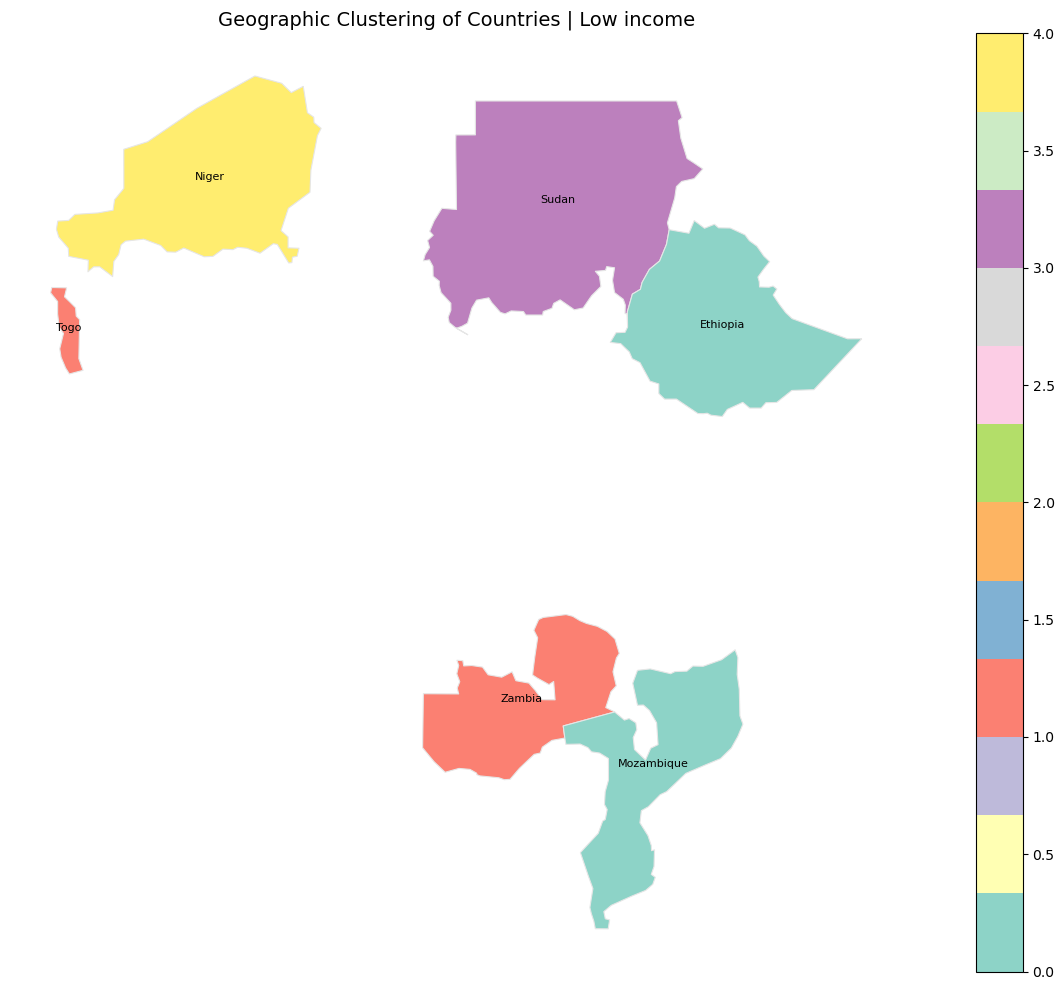

In [37]:
plot_geographic_clusters(merged_low, "Low income", shapefile_path)

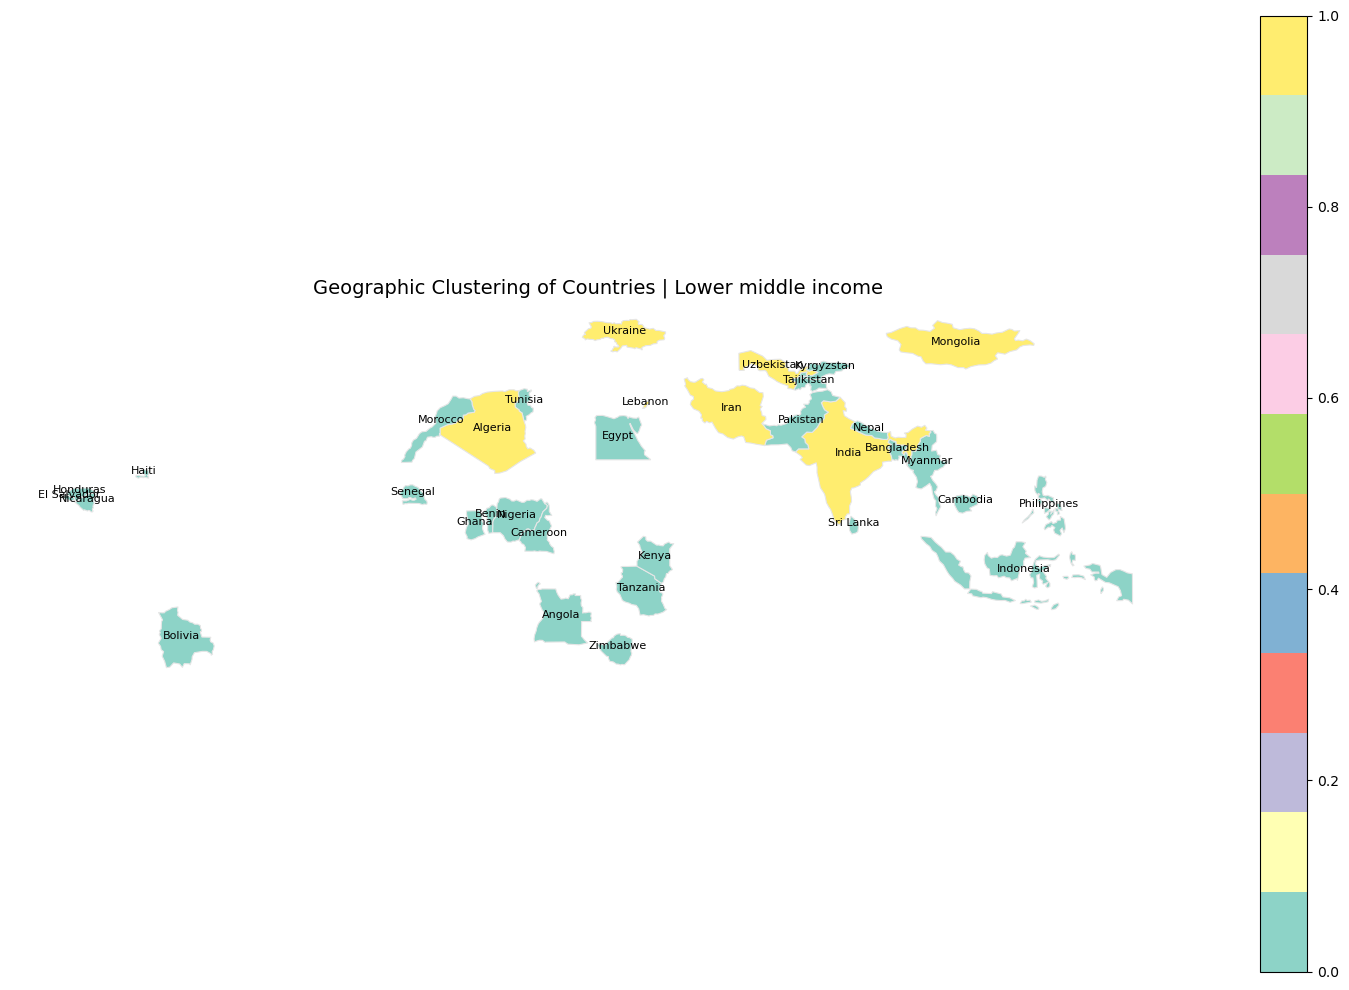

In [38]:
plot_geographic_clusters(merged_lower_middle, "Lower middle income", shapefile_path)

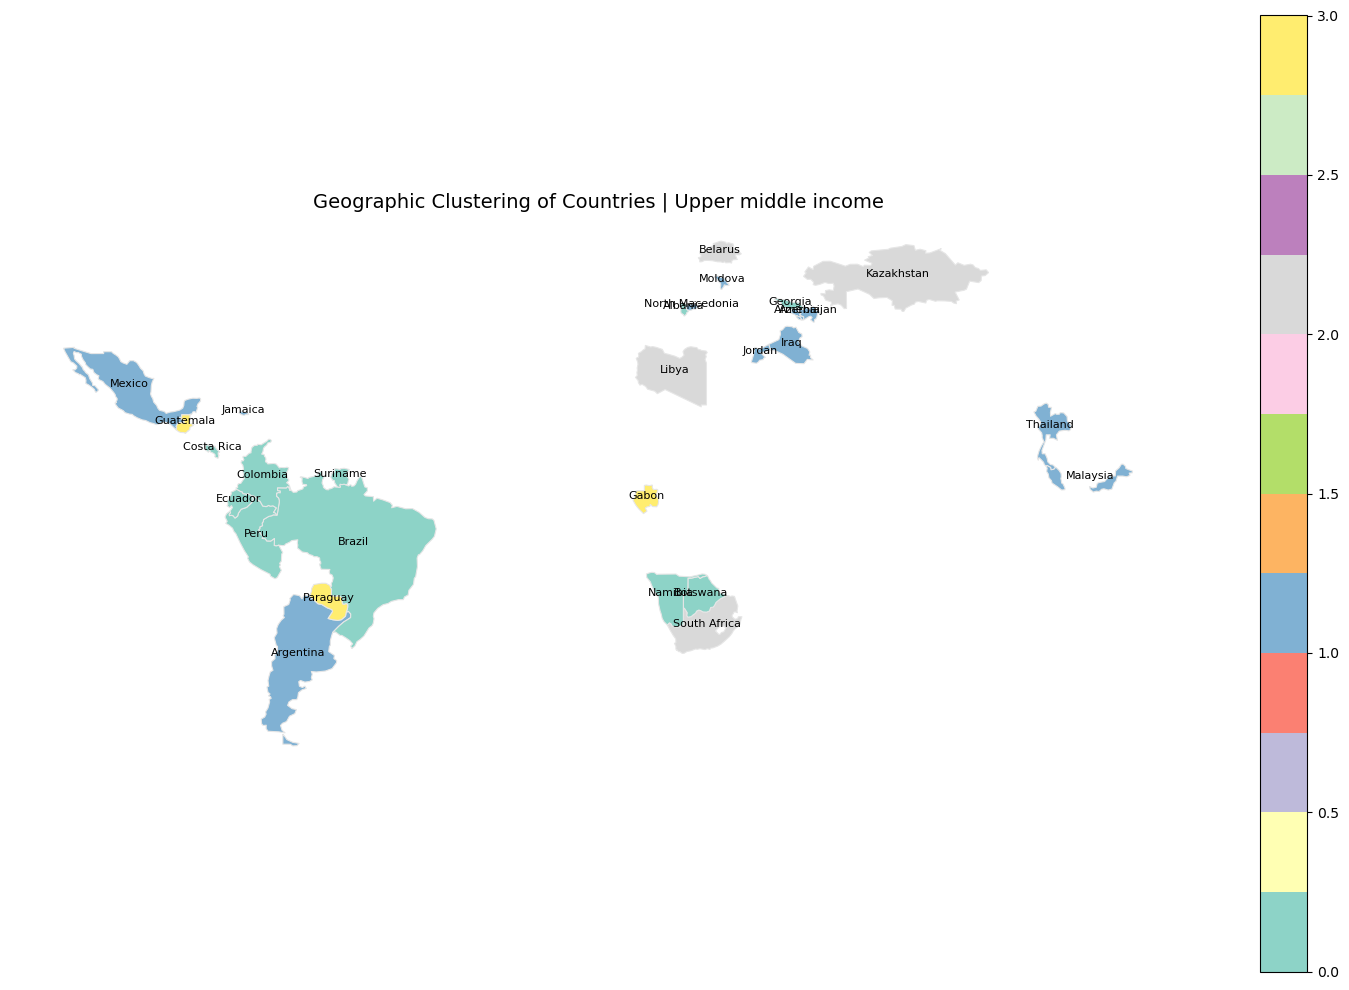

In [39]:
plot_geographic_clusters(merged_upper, "Upper middle income", shapefile_path)

In [40]:
def plot_all_income_levels_geoclusters(merged_data_dict, shapefile_path):
    world = gpd.read_file(shapefile_path)

    fig, axes = plt.subplots(1, 3, figsize=(24, 10))
    income_levels = ["Low income", "Lower middle income", "Upper middle income"]

    for i, income_level in enumerate(income_levels):
        data = merged_data_dict[income_level]
        country_clusters = data[["Country Name", "Cluster"]].drop_duplicates(subset="Country Name")

        rename_map = {
            "Congo, Dem. Rep.": "Democratic Republic of the Congo",
            "Congo, Rep.": "Republic of the Congo",
            "Egypt, Arab Rep.": "Egypt",
            "Gambia, The": "Gambia",
            "Iran, Islamic Rep.": "Iran",
            "Kyrgyz Republic": "Kyrgyzstan",
            "Lao PDR": "Laos",
            "Russian Federation": "Russia",
            "Slovak Republic": "Slovakia",
            "Syrian Arab Republic": "Syria",
            "Venezuela, RB": "Venezuela",
            "Yemen, Rep.": "Yemen"
        }
        country_clusters["Country Name"] = country_clusters["Country Name"].replace(rename_map)

        merged_map = world.merge(country_clusters, how="left", left_on="NAME", right_on="Country Name")

        merged_map.plot(column="Cluster", cmap="Set3", linewidth=0.8, edgecolor="0.9",
                        legend=True, ax=axes[i])

        for idx, row in merged_map.iterrows():
            if pd.notnull(row["Cluster"]):
                centroid = row["geometry"].centroid
                axes[i].annotate(
                    text=row["NAME"],
                    xy=(centroid.x, centroid.y),
                    ha='center',
                    fontsize=7,
                    color='black'
                )

        axes[i].set_title(f"{income_level}", fontsize=14)
        axes[i].axis("off")

    plt.suptitle("Geographic Clustering Comparison by Income Level", fontsize=18)
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

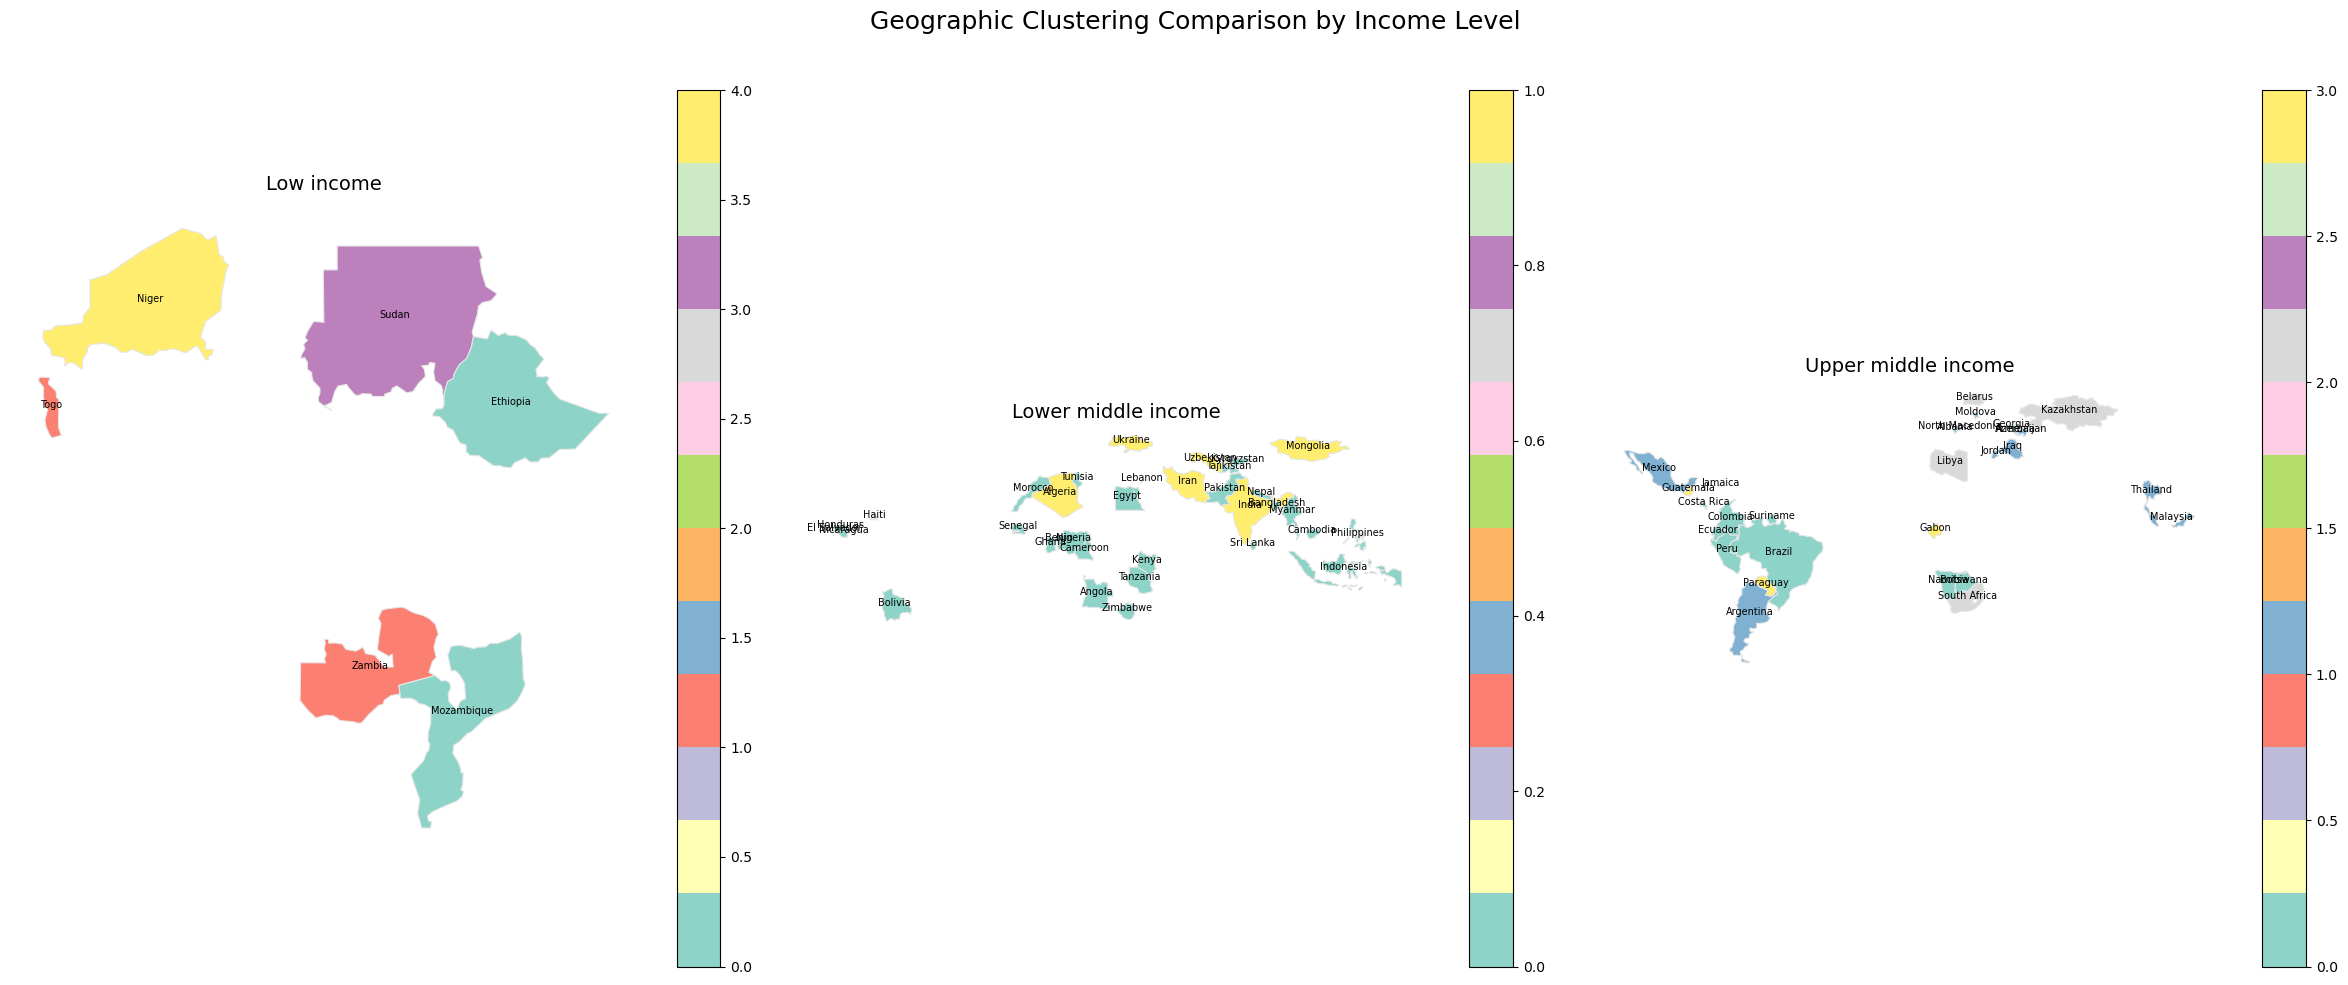

In [41]:
merged_data_dict = {
    "Low income": merged_low,
    "Lower middle income": merged_lower_middle,
    "Upper middle income": merged_upper
}

plot_all_income_levels_geoclusters(merged_data_dict, shapefile_path)